# CancerCare System - Exploratory Data Analysis

## Overview
This notebook provides comprehensive EDA for the CancerCare application, analyzing:
- Patient demographics
- Prediction results and risk levels
- Notification system patterns
- Messaging activity
- Post-diagnosis tracking
- System usage statistics

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Database connection
from core.db_config import get_session
from core.models import Patient, Prediction, Notification, Message, User, PostDiagnosis, MedicalImage, TumorMarker

session = get_session()
print("✅ Database connection established")

✅ Database connection established


## 1. Data Loading & Overview

In [3]:
# Load data into DataFrames
patients = pd.read_sql_query("SELECT * FROM patients", session.bind)
predictions = pd.read_sql_query("SELECT * FROM predictions", session.bind)
notifications = pd.read_sql_query("SELECT * FROM notifications", session.bind)
messages = pd.read_sql_query("SELECT * FROM messages", session.bind)
users = pd.read_sql_query("SELECT * FROM users", session.bind)

print("📊 Dataset Sizes:")
print(f"Patients: {len(patients)}")
print(f"Predictions: {len(predictions)}")
print(f"Notifications: {len(notifications)}")
print(f"Messages: {len(messages)}")
print(f"Users: {len(users)}")

📊 Dataset Sizes:
Patients: 29
Predictions: 32
Notifications: 0
Messages: 10
Users: 4


## 2. Patient Demographics Analysis

In [4]:
# Patient overview
print("👥 PATIENT DEMOGRAPHICS\n" + "="*50)
print(f"Total Patients: {len(patients)}")
print(f"\nAge Statistics:")
print(patients['age'].describe())
print(f"\nGender Distribution:")
print(patients['gender'].value_counts())

👥 PATIENT DEMOGRAPHICS
Total Patients: 29

Age Statistics:
count    29.000000
mean     23.862069
std       3.552908
min      19.000000
25%      20.000000
50%      24.000000
75%      27.000000
max      29.000000
Name: age, dtype: float64

Gender Distribution:
gender
M    25
F     4
Name: count, dtype: int64


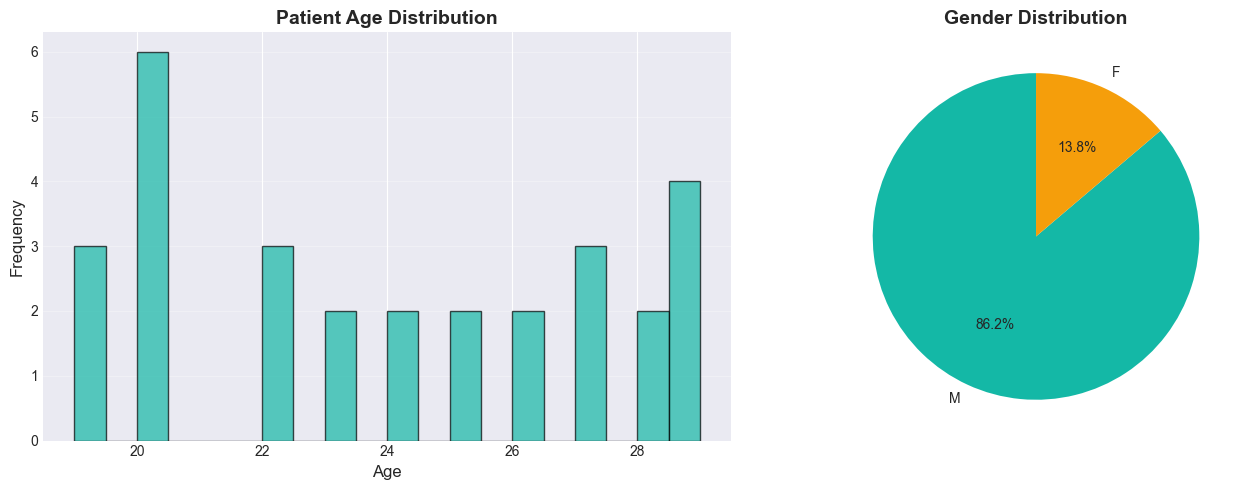

In [5]:
# Age distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
axes[0].hist(patients['age'].dropna(), bins=20, color='#14B8A6', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Patient Age Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Gender pie chart
gender_counts = patients['gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=['#14B8A6', '#F59E0B'], startangle=90)
axes[1].set_title('Gender Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Prediction Analysis

In [6]:
# Prediction statistics
print("🔮 PREDICTION ANALYSIS\n" + "="*50)
print(f"Total Predictions: {len(predictions)}")
print(f"\nRisk Level Distribution:")
print(predictions['risk_level'].value_counts())
print(f"\nConfidence Statistics:")
print(predictions['confidence'].describe())

🔮 PREDICTION ANALYSIS
Total Predictions: 32

Risk Level Distribution:
risk_level
Low       17
Medium     7
High       6
0          2
Name: count, dtype: int64

Confidence Statistics:
count    32.000000
mean      9.953069
std      28.741382
min       0.700000
25%       0.700000
50%       0.999359
75%       0.999997
max      99.998197
Name: confidence, dtype: float64


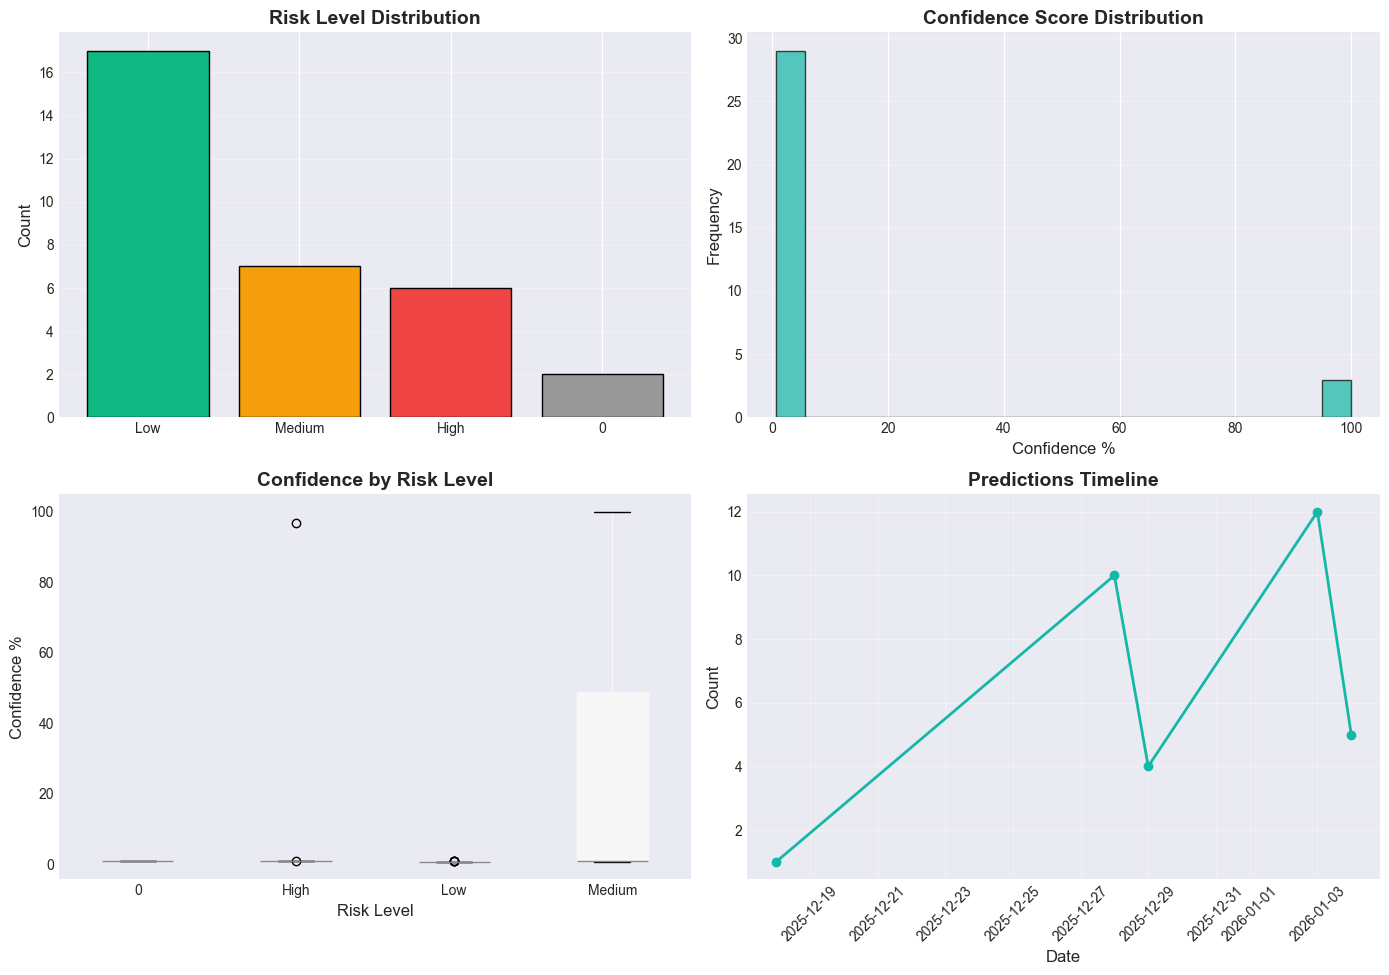

In [7]:
# Prediction visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Risk level distribution
risk_counts = predictions['risk_level'].value_counts()
colors = {'Low': '#10B981', 'Medium': '#F59E0B', 'High': '#EF4444'}
risk_colors = [colors.get(level, '#999') for level in risk_counts.index]
axes[0, 0].bar(risk_counts.index, risk_counts.values, color=risk_colors, edgecolor='black')
axes[0, 0].set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)

# Confidence distribution
axes[0, 1].hist(predictions['confidence'].dropna(), bins=20, color='#14B8A6', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Confidence %', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

# Box plot: Confidence by Risk Level
predictions.boxplot(column='confidence', by='risk_level', ax=axes[1, 0], 
                    patch_artist=True, grid=False)
axes[1, 0].set_title('Confidence by Risk Level', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Risk Level', fontsize=12)
axes[1, 0].set_ylabel('Confidence %', fontsize=12)
plt.suptitle('')  # Remove default title

# Predictions over time
if 'created_at' in predictions.columns and len(predictions) > 0:
    predictions['created_at'] = pd.to_datetime(predictions['created_at'])
    predictions['date'] = predictions['created_at'].dt.date
    daily_counts = predictions.groupby('date').size()
    axes[1, 1].plot(daily_counts.index, daily_counts.values, marker='o', color='#14B8A6', linewidth=2)
    axes[1, 1].set_title('Predictions Timeline', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Date', fontsize=12)
    axes[1, 1].set_ylabel('Count', fontsize=12)
    axes[1, 1].grid(alpha=0.3)
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 4. Risk Analysis by Demographics

In [8]:
# Merge patients with predictions
patient_predictions = predictions.merge(patients, left_on='patient_id', right_on='id', suffixes=('_pred', '_patient'))

# Age groups
patient_predictions['age_group'] = pd.cut(patient_predictions['age'], 
                                          bins=[0, 30, 40, 50, 60, 70, 100], 
                                          labels=['<30', '30-40', '40-50', '50-60', '60-70', '70+'])

# Risk by age group
risk_by_age = pd.crosstab(patient_predictions['age_group'], patient_predictions['risk_level'])
print("\n📊 Risk Distribution by Age Group:")
print(risk_by_age)


📊 Risk Distribution by Age Group:
risk_level  0  High  Low  Medium
age_group                       
<30         2     6   17       7


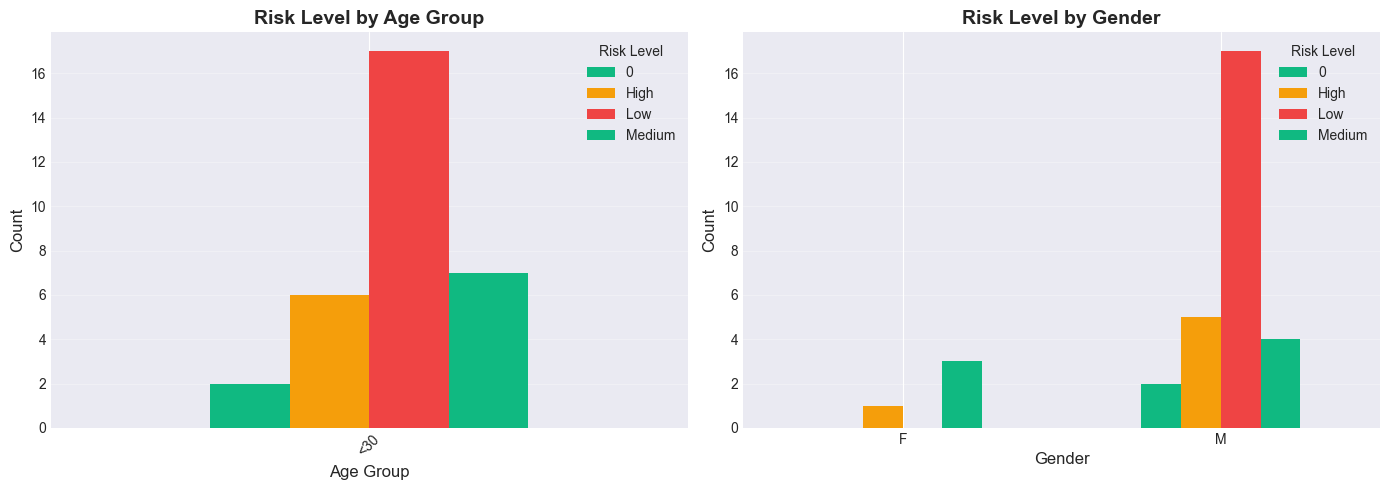

In [9]:
# Visualize risk by demographics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk by age group
risk_by_age.plot(kind='bar', stacked=False, ax=axes[0], 
                 color=['#10B981', '#F59E0B', '#EF4444'])
axes[0].set_title('Risk Level by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Risk Level')
axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Risk by gender
risk_by_gender = pd.crosstab(patient_predictions['gender'], patient_predictions['risk_level'])
risk_by_gender.plot(kind='bar', ax=axes[1], 
                    color=['#10B981', '#F59E0B', '#EF4444'])
axes[1].set_title('Risk Level by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(title='Risk Level')
axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 5. Notification System Analysis

In [10]:
# Notification statistics
print("🔔 NOTIFICATION ANALYSIS\n" + "="*50)
print(f"Total Notifications: {len(notifications)}")
print(f"\nPriority Distribution:")
print(notifications['priority'].value_counts())
print(f"\nType Distribution:")
print(notifications['type'].value_counts())
print(f"\nRead Status:")
print(f"Read: {notifications['is_read'].sum()}")
print(f"Unread: {(~notifications['is_read']).sum()}")

🔔 NOTIFICATION ANALYSIS
Total Notifications: 0

Priority Distribution:
Series([], Name: count, dtype: int64)

Type Distribution:
Series([], Name: count, dtype: int64)

Read Status:
Read: 0
Unread: 0


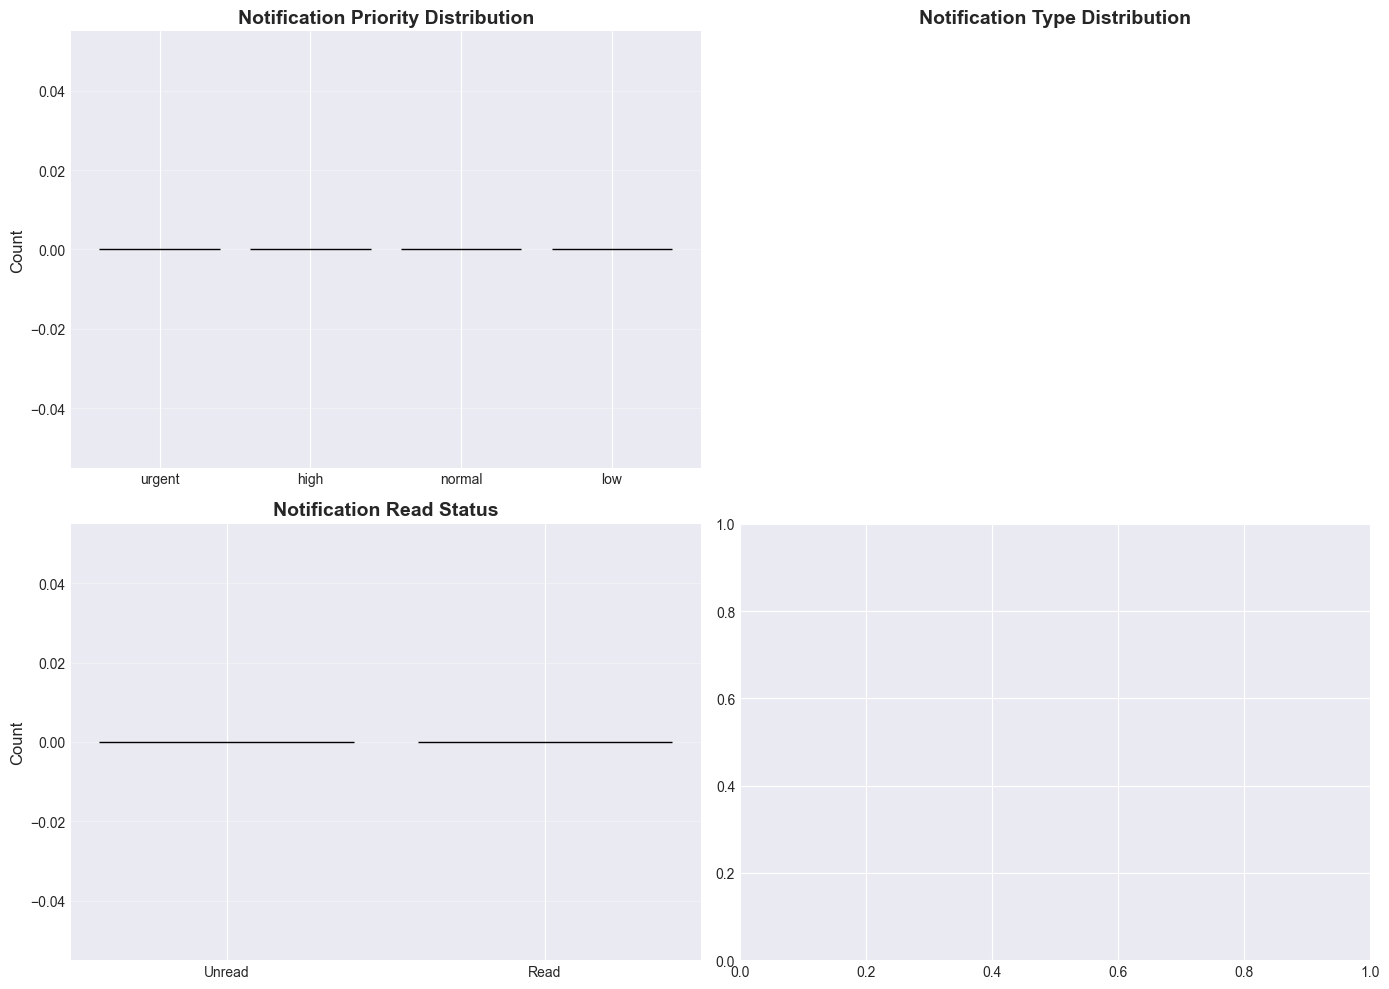

In [11]:
# Notification visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Priority distribution
priority_order = ['urgent', 'high', 'normal', 'low']
priority_counts = notifications['priority'].value_counts().reindex(priority_order, fill_value=0)
priority_colors = {'urgent': '#DC2626', 'high': '#F59E0B', 'normal': '#14B8A6', 'low': '#94A3B8'}
colors_list = [priority_colors.get(p, '#999') for p in priority_counts.index]
axes[0, 0].bar(priority_counts.index, priority_counts.values, color=colors_list, edgecolor='black')
axes[0, 0].set_title('Notification Priority Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)

# Type distribution
type_counts = notifications['type'].value_counts()
axes[0, 1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Notification Type Distribution', fontsize=14, fontweight='bold')

# Read status
read_counts = notifications['is_read'].value_counts()
axes[1, 0].bar(['Unread', 'Read'], [read_counts.get(False, 0), read_counts.get(True, 0)], 
               color=['#F59E0B', '#10B981'], edgecolor='black')
axes[1, 0].set_title('Notification Read Status', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)

# Notifications timeline
if 'created_at' in notifications.columns and len(notifications) > 0:
    notifications['created_at'] = pd.to_datetime(notifications['created_at'])
    notifications['hour'] = notifications['created_at'].dt.hour
    hourly_counts = notifications.groupby('hour').size()
    axes[1, 1].bar(hourly_counts.index, hourly_counts.values, color='#14B8A6', edgecolor='black')
    axes[1, 1].set_title('Notifications by Hour of Day', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Hour', fontsize=12)
    axes[1, 1].set_ylabel('Count', fontsize=12)
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Messaging System Analysis

In [12]:
# Message statistics
print("💬 MESSAGING ANALYSIS\n" + "="*50)
print(f"Total Messages: {len(messages)}")
print(f"\nRead Status:")
print(f"Read: {messages['is_read'].sum()}")
print(f"Unread: {(~messages['is_read']).sum()}")
print(f"\nPriority Distribution:")
print(messages['priority'].value_counts())
print(f"\nThreaded Messages: {messages['parent_message_id'].notna().sum()}")
print(f"Unique Conversations: {messages['thread_id'].nunique()}")

💬 MESSAGING ANALYSIS
Total Messages: 10

Read Status:
Read: 4
Unread: -14

Priority Distribution:
priority
high      4
normal    4
low       2
Name: count, dtype: int64

Threaded Messages: 4
Unique Conversations: 6


In [13]:
# Overall system metrics
print("📈 SYSTEM USAGE METRICS\n" + "="*50)
print(f"Active Users: {users['is_active'].sum()}")
print(f"User Roles:")
print(users['role'].value_counts())
print(f"\nPredictions per Patient (avg): {len(predictions) / max(len(patients), 1):.2f}")
print(f"Notifications per User (avg): {len(notifications) / max(len(users), 1):.2f}")
print(f"Messages per User (avg): {len(messages) / max(len(users), 1):.2f}")

📈 SYSTEM USAGE METRICS
Active Users: 4
User Roles:
role
admin      2
doctor     1
patient    1
Name: count, dtype: int64

Predictions per Patient (avg): 1.10
Notifications per User (avg): 0.00
Messages per User (avg): 2.50


## 7. System Usage & Performance Metrics

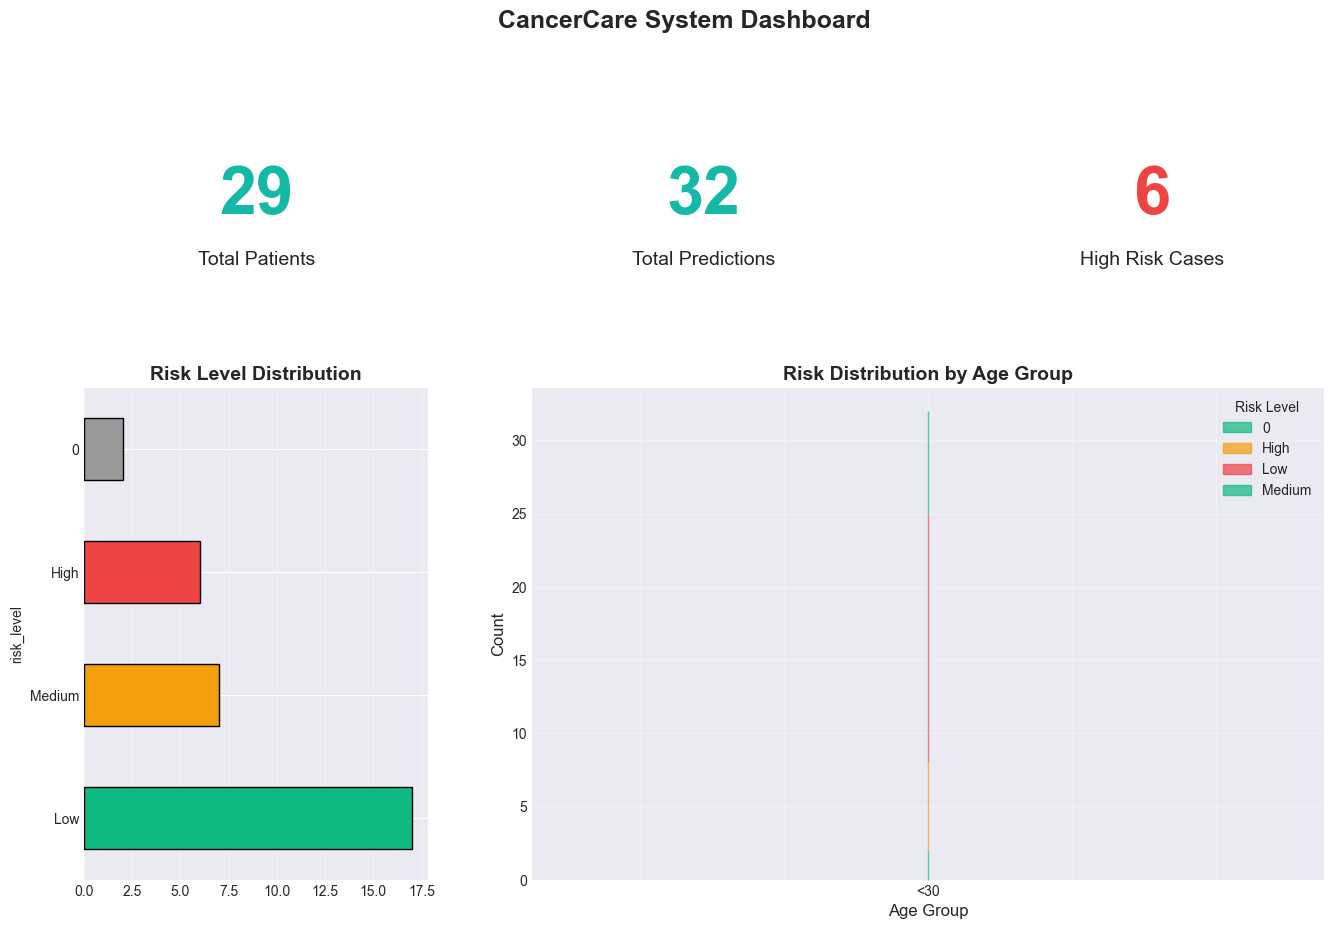

In [14]:
# Create summary dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# KPI cards
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.6, str(len(patients)), ha='center', va='center', fontsize=48, color='#14B8A6', fontweight='bold')
ax1.text(0.5, 0.3, 'Total Patients', ha='center', va='center', fontsize=14)
ax1.axis('off')
ax1.set_facecolor('#F0FDFA')

ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.6, str(len(predictions)), ha='center', va='center', fontsize=48, color='#14B8A6', fontweight='bold')
ax2.text(0.5, 0.3, 'Total Predictions', ha='center', va='center', fontsize=14)
ax2.axis('off')
ax2.set_facecolor('#F0FDFA')

ax3 = fig.add_subplot(gs[0, 2])
high_risk = predictions[predictions['risk_level'] == 'High'].shape[0]
ax3.text(0.5, 0.6, str(high_risk), ha='center', va='center', fontsize=48, color='#EF4444', fontweight='bold')
ax3.text(0.5, 0.3, 'High Risk Cases', ha='center', va='center', fontsize=14)
ax3.axis('off')
ax3.set_facecolor('#FEF2F2')

# Main charts
ax4 = fig.add_subplot(gs[1:, 0])
risk_counts.plot(kind='barh', ax=ax4, color=risk_colors, edgecolor='black')
ax4.set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

ax5 = fig.add_subplot(gs[1:, 1:])
if len(patient_predictions) > 0:
    risk_by_age.plot(kind='area', ax=ax5, alpha=0.7, color=['#10B981', '#F59E0B', '#EF4444'])
    ax5.set_title('Risk Distribution by Age Group', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Age Group', fontsize=12)
    ax5.set_ylabel('Count', fontsize=12)
    ax5.legend(title='Risk Level')
    ax5.grid(alpha=0.3)

plt.suptitle('CancerCare System Dashboard', fontsize=18, fontweight='bold', y=0.98)
plt.show()

## 8. Key Insights & Recommendations

In [15]:
print("\n" + "="*70)
print("📋 KEY INSIGHTS & RECOMMENDATIONS")
print("="*70)

# Calculate insights
if len(predictions) > 0:
    high_risk_pct = (predictions['risk_level'] == 'High').sum() / len(predictions) * 100
    avg_confidence = predictions['confidence'].mean()
    
    print(f"\n1. PREDICTION INSIGHTS:")
    print(f"   • {high_risk_pct:.1f}% of predictions are high-risk cases")
    print(f"   • Average prediction confidence: {avg_confidence:.1f}%")
    print(f"   • Model performance appears {'strong' if avg_confidence > 80 else 'moderate'}")

if len(patient_predictions) > 0:
    print(f"\n2. DEMOGRAPHIC INSIGHTS:")
    high_risk_age = patient_predictions[patient_predictions['risk_level'] == 'High']['age'].mean()
    print(f"   • Average age of high-risk patients: {high_risk_age:.1f} years")
    print(f"   • Age range: {patients['age'].min()}-{patients['age'].max()} years")

if len(notifications) > 0:
    unread_pct = (~notifications['is_read']).sum() / len(notifications) * 100
    print(f"\n3. NOTIFICATION SYSTEM:")
    print(f"   • {unread_pct:.1f}% of notifications are unread")
    print(f"   • Recommendation: {'Review notification strategy' if unread_pct > 50 else 'System performing well'}")

if len(messages) > 0:
    msg_unread_pct = (~messages['is_read']).sum() / len(messages) * 100
    print(f"\n4. MESSAGING ACTIVITY:")
    print(f"   • {msg_unread_pct:.1f}% of messages are unread")
    print(f"   • {messages['thread_id'].nunique()} active conversation threads")

print(f"\n5. SYSTEM RECOMMENDATIONS:")
if high_risk_pct > 30:
    print(f"   • High percentage of high-risk cases - consider adding more preventive screening")
if avg_confidence < 75:
    print(f"   • Model confidence could be improved - consider retraining with more data")
print(f"   • Continue monitoring notification and messaging engagement")
print(f"   • System appears to be functioning well with {len(users)} active users")

print("\n" + "="*70)


📋 KEY INSIGHTS & RECOMMENDATIONS

1. PREDICTION INSIGHTS:
   • 18.8% of predictions are high-risk cases
   • Average prediction confidence: 10.0%
   • Model performance appears moderate

2. DEMOGRAPHIC INSIGHTS:
   • Average age of high-risk patients: 24.7 years
   • Age range: 19-29 years

4. MESSAGING ACTIVITY:
   • -140.0% of messages are unread
   • 6 active conversation threads

5. SYSTEM RECOMMENDATIONS:
   • Model confidence could be improved - consider retraining with more data
   • Continue monitoring notification and messaging engagement
   • System appears to be functioning well with 4 active users



## 9. Export Summary Statistics

In [16]:
# Create summary report
summary_stats = {
    'Total Patients': len(patients),
    'Total Predictions': len(predictions),
    'High Risk Cases': (predictions['risk_level'] == 'High').sum() if len(predictions) > 0 else 0,
    'Average Confidence': predictions['confidence'].mean() if len(predictions) > 0 else 0,
    'Total Notifications': len(notifications),
    'Unread Notifications': (~notifications['is_read']).sum() if len(notifications) > 0 else 0,
    'Total Messages': len(messages),
    'Active Users': users['is_active'].sum() if len(users) > 0 else 0
}

summary_df = pd.DataFrame(summary_stats.items(), columns=['Metric', 'Value'])
summary_df.to_csv('CancerCare_Summary_Statistics.csv', index=False)

print("✅ Summary statistics exported to 'CancerCare_Summary_Statistics.csv'")
print("\n📊 Summary:")
print(summary_df.to_string(index=False))

✅ Summary statistics exported to 'CancerCare_Summary_Statistics.csv'

📊 Summary:
              Metric     Value
      Total Patients 29.000000
   Total Predictions 32.000000
     High Risk Cases  6.000000
  Average Confidence  9.953069
 Total Notifications  0.000000
Unread Notifications  0.000000
      Total Messages 10.000000
        Active Users  4.000000


In [17]:
# Close database session
session.close()
print("\n✅ Analysis complete! Database session closed.")


✅ Analysis complete! Database session closed.


In [18]:
# Message visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Read/Unread
msg_read_counts = messages['is_read'].value_counts()
axes[0].pie([msg_read_counts.get(False, 0), msg_read_counts.get(True, 0)], 
            labels=['Unread', 'Read'], autopct='%1.1f%%', 
            colors=['#F59E0B', '#10B981'], startangle=90)
axes[0].set_title('Message Read Status', fontsize=14, fontweight='bold')

# Messages per user
sender_counts = messages['sender_id'].value_counts().head(10)
axes[1].barh(range(len(sender_counts)), sender_counts.values, color='#14B8A6', edgecolor='black')
axes[1].set_yticks(range(len(sender_counts)))
axes[1].set_yticklabels([f'User {uid}' for uid in sender_counts.index])
axes[1].set_title('Top Message Senders', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Message Count', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 1400x500 with 2 Axes>